# Experiment 05: Activation Frequency-Guided Tensor Compression (Branch 1)

**Target Model**: `google/gemma-3-1b-it` (Layer 0 `model.layers[0]`, Submodules: `mlp.gate_proj` & `mlp.act_fn`)  
**Evaluation Task**: GLUE MNLI Validation Set (`validation_matched`)  

### Key Pipeline Principles:
1. **Initial Benchmarking on Unprocessed Weights**: Run baseline inference with pristine weights ($W_{\text{orig}}$). A forward hook captures activation trajectories for all coordinates.
2. **Activation Outlier Filter**: Quarantines extreme superweights ($|x| > 3.0$ or top 1% variance) in uncompressed FP32.
3. **1D Activation Frequency Metric**: For each coordinate, extracts `{coordinate: Top_most_K_frequent_activation_value}` ($v_c \in \mathbb{R}$) representing its primary operating mode.
4. **1D Absolute Difference Similarity $s(x, y) = S$**:
   $$d(x, y) = |v_x - v_y| \quad \text{(Absolute Difference)}$$
   $$s(x, y) = 1.0 - \frac{|v_x - v_y|}{\Delta v_{\max}} \in [0, 1]$$
5. **Mutually Exclusive Grouping**: Sorts coordinates along this 1D axis and partitions them into $N$ contiguous clusters with minimal intra-cluster absolute difference.
6. **d-Way Tensor Construction & Tucker**: Stacks corresponding cluster weight matrices into a 3D tensor $\mathcal{T}$ and decomposes via Tucker.

In [1]:
# =====================================================================
# STEP 1: Environment Setup, Time Logging & Library Imports
# =====================================================================
import os
import sys
import time
from pathlib import Path
import math
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor
from datasets import load_dataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from IPython import get_ipython

# Set TensorLy PyTorch backend
tl.set_backend("pytorch")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Minimal Time Logging
GLOBAL_NOTEBOOK_START_TIME = time.time()
NOTEBOOK_TIMINGS = []
_current_cell_start = None

ip = get_ipython()
if ip is not None:
    def _pre_cell_hook(info):
        global _current_cell_start
        _current_cell_start = time.time()

    def _post_cell_hook(result):
        global _current_cell_start
        if _current_cell_start is not None:
            elapsed = time.time() - _current_cell_start
            cumulative = time.time() - GLOBAL_NOTEBOOK_START_TIME
            cell_id = result.execution_count or len(NOTEBOOK_TIMINGS) + 1

            timing_entry = {
                "cell_id": cell_id,
                "time": round(elapsed, 3),
                "cummulative_time": round(cumulative, 3),
            }
            NOTEBOOK_TIMINGS.append(timing_entry)

            print(f"time: {elapsed:.2f}s")
            print(f"cummulative_time: {cumulative:.2f}s")

    ip.events.register("pre_run_cell", _pre_cell_hook)
    ip.events.register("post_run_cell", _post_cell_hook)

# Neural Decomp framework imports
try:
    from neural_decomp import ModelManagementInterface, DeviceMapOptions
    from neural_decomp.decomposition import decompose_svd, truncate_svd, decompose_tucker
    from neural_decomp.utils import get_device_info, save_json_metrics
    print("Loaded neural_decomp library.")
except ImportError:
    from utility import ModelManagementInterface, DeviceMapOptions
    from utility.decomposition import decompose_svd, truncate_svd, decompose_tucker
    from utility.utils import get_device_info, save_json_metrics
    print("Loaded utility library.")

device_info = get_device_info()
print(f"Device: {device_info['device_name']} | CUDA Available: {device_info['cuda_available']}")

/home/dwithun/Development/llm_compression/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded neural_decomp library.
Device: NVIDIA GeForce RTX 3070 Ti | CUDA Available: True


In [2]:
# =====================================================================
# STEP 2: Initialize Model & Tokenizer (Unprocessed Clean Baseline)
# =====================================================================
model_id = "google/gemma-3-1b-it"

mmi = ModelManagementInterface(
    model_id=model_id,
    precision=torch.float32,
    device_map=DeviceMapOptions.AUTO,
)
model = mmi.get_model()
tokenizer = mmi.get_tokenizer()

# Target Feedforward Layer 0
target_layer = model.model.layers[0]
target_submodule = target_layer.mlp.gate_proj

print(f"Target Submodule: gate_proj ({target_submodule.weight.shape[0]} x {target_submodule.weight.shape[1]})")

# Store pristine unprocessed original weights for calibration and rollbacks
W_gate_orig = target_submodule.weight.data.clone()

Loading weights: 100%|██████████| 340/340 [00:03<00:00, 92.29it/s] 


Target Submodule: gate_proj (6912 x 1152)
time: 7.27s
cummulative_time: 9.99s


In [3]:
# =====================================================================
# STEP 3: Load GLUE MNLI Validation Benchmark
# =====================================================================
ds = load_dataset("nyu-mll/glue", "mnli")["validation_matched"]

label_names = ["entailment", "neutral", "contradiction"]
label_token_ids = [tokenizer.encode(" " + name, add_special_tokens=False)[0] for name in label_names]

# Sample limit for initial benchmark profiling
EVAL_SAMPLE_COUNT = 150
eval_data = ds.select(range(EVAL_SAMPLE_COUNT))

print(f"Loaded GLUE MNLI: {len(ds):,} total samples | Active Evaluation Subset: {len(eval_data):,} samples")

Loaded GLUE MNLI: 9,815 total samples | Active Evaluation Subset: 150 samples
time: 3.60s
cummulative_time: 13.59s


## Step 1: Initial Benchmarking on Unprocessed Weights & Frequency Hook (`freq_hook`)

We evaluate the pristine, uncompressed model on the initial benchmark samples.
Forward hook `freq_hook()` records the raw activation values for all coordinates in Layer 0 `mlp.act_fn`:
$$\text{freq\_hook}() = \{\text{coordinate } j: \text{activation\_values over each bench sample } [v_1, v_2, \dots, v_P]\}$$
This provides the empirical activation distributions on unprocessed weights.

In [4]:
# =====================================================================
# STEP 4: Initial Benchmarking on Unprocessed Weights
# =====================================================================
# freq_hook storage: captures {coordinate: activation_values over_each_bench_sample[]}
activation_trajectories = []
current_act = None

def freq_hook(module, input_tensor, output_tensor):
    global current_act
    act = output_tensor[0] if isinstance(output_tensor, tuple) else output_tensor
    current_act = act.detach().cpu()

h = target_layer.mlp.act_fn.register_forward_hook(freq_hook)

predictions = []
ground_truth = []

model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Initial Benchmarking on Unprocessed Weights"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
            f"Answer with one word\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model(**inputs)

        # Mean-pool over sequence length to obtain 1D activation vector per sample: [6912]
        if current_act is not None:
            pooled = current_act.squeeze(0).mean(dim=0).numpy()
            activation_trajectories.append(pooled)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]
        pred_label = torch.argmax(candidate_logits).item()

        predictions.append(pred_label)
        ground_truth.append(sample["label"])

h.remove()

# Raw activation matrix on unprocessed weights: [num_samples, 6912]
acts_matrix = np.stack(activation_trajectories)

baseline_accuracy = accuracy_score(ground_truth, predictions)
print(f"\nUncompressed Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Captured Activation Trajectory Matrix: {acts_matrix.shape}")

Initial Benchmarking on Unprocessed Weights: 100%|██████████| 150/150 [00:07<00:00, 21.37it/s]


Uncompressed Baseline Accuracy: 50.67%
Captured Activation Trajectory Matrix: (150, 6912)
time: 7.04s
cummulative_time: 20.63s


## Step 2: Activation Outlier Filter & 1D Frequent Value Extraction

1. **Outlier Filter**: Separates extreme superweight coordinates ($|x| > 3.0$ or top 1% variance) from normal activation values. Superweights are quarantined to remain uncompressed.
2. **Branch 1 Extraction**: For each coordinate $c$, extracts the 1D scalar:
   $$v_c = \text{Top\_most\_K\_frequent\_activation\_value}$$
   by rounding activation values to 1 decimal place and identifying the modal activation value.

In [5]:
# =====================================================================
# STEP 5: Outlier Filter (Superweights) & 1D Frequent Value Extraction
# =====================================================================
num_samples, total_coords = acts_matrix.shape

# 1. Activation Outlier Filter: Identify extreme superweights
max_magnitudes = np.max(np.abs(acts_matrix), axis=0)
variances = np.var(acts_matrix, axis=0)

OUTLIER_THRESHOLD = 3.0
superweight_mask = (max_magnitudes > OUTLIER_THRESHOLD) | (variances >= np.quantile(variances, 0.99))
superweight_indices = np.where(superweight_mask)[0]

# Dead / Inactive coordinates (< 0.05 on > 90% of samples)
inactive_mask = (np.mean(np.abs(acts_matrix) < 0.05, axis=0) > 0.90) & (~superweight_mask)
inactive_indices = np.where(inactive_mask)[0]

# Normal active coordinates to be compressed
normal_active_mask = (~superweight_mask) & (~inactive_mask)
normal_active_indices = np.where(normal_active_mask)[0]

print(f"Total Coordinates:           {total_coords:,}")
print(f"Superweight Coordinates:     {len(superweight_indices):,} ({len(superweight_indices)/total_coords*100:.1f}%) [Quarantined]")
print(f"Inactive Coordinates:        {len(inactive_indices):,} ({len(inactive_indices)/total_coords*100:.1f}%)")
print(f"Normal Active Coordinates:   {len(normal_active_indices):,} ({len(normal_active_indices)/total_coords*100:.1f}%) [Target for Tucker]")

# 2. Extract 1D Top Most Frequent Activation Value (v_c) for each normal active coordinate
rounded_acts = np.round(acts_matrix[:, normal_active_indices], decimals=1)

top_frequent_values = []
for idx_in_active in range(len(normal_active_indices)):
    vals, counts = np.unique(rounded_acts[:, idx_in_active], return_counts=True)
    top_val = vals[np.argmax(counts)]
    top_frequent_values.append(top_val)

top_frequent_values = np.array(top_frequent_values)
print(f"Extracted 1D Top Frequent Values vector: shape = {top_frequent_values.shape}")
print(f"1D Value Range: min = {top_frequent_values.min():.2f}, max = {top_frequent_values.max():.2f}, mean = {top_frequent_values.mean():.2f}")

Total Coordinates:           6,912
Superweight Coordinates:     71 (1.0%) [Quarantined]
Inactive Coordinates:        1,315 (19.0%)
Normal Active Coordinates:   5,526 (79.9%) [Target for Tucker]
Extracted 1D Top Frequent Values vector: shape = (5526,)
1D Value Range: min = -0.10, max = 2.70, mean = 0.09
time: 0.07s
cummulative_time: 20.71s


## Step 3: Similarity Indexing via 1D Absolute Difference

Because differentiating is 1-dimensional, the distance between coordinates $x$ and $y$ is the **absolute difference**:
$$d(x, y) = |v_x - v_y|$$
The corresponding similarity index is:
$$s(x, y) = 1.0 - \frac{|v_x - v_y|}{\max |v_i - v_j|} \in [0, 1]$$
Sorting coordinates along this 1D scalar and slicing contiguous chunks guarantees **minimal intra-cluster absolute difference** for all mutually exclusive groups.

Cluster    | Size   | Value Range [min, max]     | Max Abs Diff   | Mean Sim S
---------------------------------------------------------------------------
Cluster 0   | 400    | [ -0.10,  -0.10]           |       0.00   |   1.0000
Cluster 1   | 400    | [ -0.10,  -0.10]           |       0.00   |   1.0000
Cluster 2   | 400    | [ -0.10,  -0.10]           |       0.00   |   1.0000
Cluster 3   | 400    | [ -0.10,  -0.10]           |       0.00   |   1.0000
Cluster 4   | 400    | [ -0.10,  -0.00]           |       0.10   |   0.0000
Cluster 5   | 400    | [ -0.00,  -0.00]           |       0.00   |   1.0000
---------------------------------------------------------------------------
Total Mutually Exclusive Coordinates Grouped: 2,400


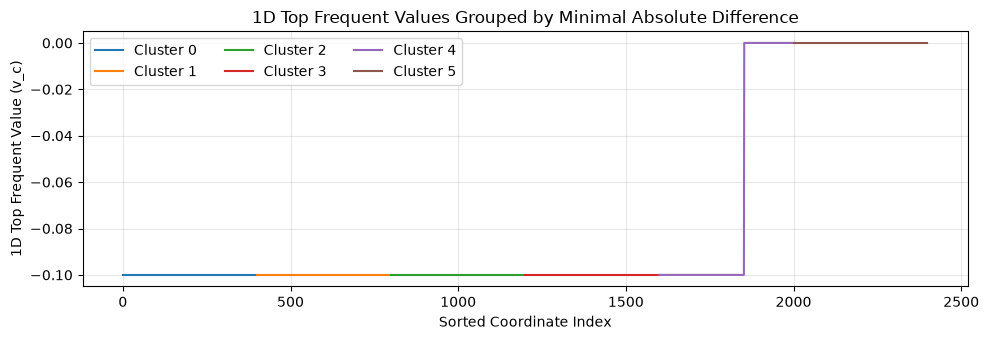

time: 0.17s
cummulative_time: 20.89s


In [6]:
# =====================================================================
# STEP 6: 1D Absolute Difference Grouping & Mutually Exclusive Clusters
# =====================================================================
NUM_CLUSTERS = 6
COORDS_PER_CLUSTER = 400  # Total 6 x 400 = 2,400 active coordinates
TARGET_TOTAL_ACTIVE = NUM_CLUSTERS * COORDS_PER_CLUSTER

# 1. Sort coordinates by their 1D top frequent activation value
# In 1D, sorting globally minimizes intra-cluster absolute difference |v_x - v_y|
sorted_local_order = np.argsort(top_frequent_values)
selected_local_indices = sorted_local_order[:TARGET_TOTAL_ACTIVE]
selected_active_coords = normal_active_indices[selected_local_indices]
selected_values = top_frequent_values[selected_local_indices]

# 2. Maximum possible 1D span for normalized similarity scaling
val_span = max(selected_values.max() - selected_values.min(), 1e-6)

clusters_dict = {}
print(f"{'Cluster':<10} | {'Size':<6} | {'Value Range [min, max]':<26} | {'Max Abs Diff':<14} | {'Mean Sim S':<10}")
print("-" * 75)

for k in range(NUM_CLUSTERS):
    start_idx = k * COORDS_PER_CLUSTER
    end_idx = (k + 1) * COORDS_PER_CLUSTER
    
    cluster_coords = selected_active_coords[start_idx:end_idx]
    cluster_vals = selected_values[start_idx:end_idx]
    clusters_dict[k] = cluster_coords
    
    # Intra-cluster absolute difference and similarity metrics
    max_abs_diff = cluster_vals.max() - cluster_vals.min()
    mean_sim_S = 1.0 - (max_abs_diff / val_span)
    
    print(f"Cluster {k:<3} | {len(cluster_coords):<6} | [{cluster_vals.min():>6.2f}, {cluster_vals.max():>6.2f}]           | {max_abs_diff:>10.2f}   | {mean_sim_S:>8.4f}")

print("-" * 75)
print(f"Total Mutually Exclusive Coordinates Grouped: {sum(len(c) for c in clusters_dict.values()):,}")

# Visualizing 1D values across sorted clusters
plt.figure(figsize=(10, 3.5))
for k in range(NUM_CLUSTERS):
    start_idx = k * COORDS_PER_CLUSTER
    end_idx = (k + 1) * COORDS_PER_CLUSTER
    plt.plot(range(start_idx, end_idx), selected_values[start_idx:end_idx], label=f"Cluster {k}")

plt.title("1D Top Frequent Values Grouped by Minimal Absolute Difference", fontsize=12)
plt.xlabel("Sorted Coordinate Index")
plt.ylabel("1D Top Frequent Value (v_c)")
plt.legend(ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Create Mutually Exclusive $d$-Way Tensors & Apply Tucker Decomposition

For each mutually exclusive cluster $k$, we extract the corresponding weight slice:
$$W_k = W_{\text{gate}}[\text{cluster}_k, :] \in \mathbb{R}^{M \times 1152}$$
We stack all $N$ cluster matrices into a **3D tensor** $\mathcal{T} \in \mathbb{R}^{N \times M \times 1152}$:
$$\text{Tucker}(\mathcal{T}) = \mathcal{S} \times_1 A \times_2 B \times_3 C$$
Because coordinates in each slice were grouped by minimal absolute difference, intra-cluster variance is tightly bounded.

In [7]:
# =====================================================================
# STEP 7: Assemble d-Way Tensor T & Run Tucker Decomposition
# =====================================================================
D_IN = target_submodule.weight.shape[1]  # 1152

cluster_weight_slices = []
for k in range(NUM_CLUSTERS):
    W_k = W_gate_orig[clusters_dict[k], :].float().cpu()
    cluster_weight_slices.append(W_k)

# Stacked 3D Tensor T: [N=6, M=400, D=1152]
T = torch.stack(cluster_weight_slices, dim=0)
print(f"Stacked 3D Tensor T shape: {list(T.shape)} ({T.numel():,} parameters)")

W_stacked_orig = T.reshape(-1, D_IN)

tucker_configs = [
    {"label": "Tucker Balanced",   "ranks": [4, 250, 800]},
    {"label": "Tucker Moderate",   "ranks": [4, 180, 600]},
    {"label": "Tucker Aggressive", "ranks": [3, 120, 450]},
]

decomp_results = {}

for cfg in tucker_configs:
    ranks = cfg["ranks"]
    core, factors = tucker(T, rank=ranks, init='svd')
    
    # Reconstruct 3D Tensor
    T_recon = tucker_to_tensor((core, factors))
    W_recon_stacked = T_recon.reshape(-1, D_IN)
    
    # Relative Frobenius reconstruction error
    rel_error = (torch.norm(W_stacked_orig - W_recon_stacked) / torch.norm(W_stacked_orig)).item()
    
    # Parameter accounting: Core + Factor Matrices
    core_params = core.numel()
    factor_params = sum(f.numel() for f in factors)
    total_compressed = core_params + factor_params
    orig_params = T.numel()
    comp_ratio = orig_params / total_compressed
    eliminated_pct = (1.0 - total_compressed / orig_params) * 100.0
    
    print(f"\n{cfg['label']} (Ranks {ranks}):")
    print(f"  Reconstruction Error: {rel_error * 100:.2f}%")
    print(f"  Core Parameters:      {core_params:,}")
    print(f"  Factor Parameters:    {factor_params:,}")
    print(f"  Total Compressed:     {total_compressed:,} vs Original {orig_params:,} ({comp_ratio:.2f}x)")
    print(f"  Parameters Cut:       {eliminated_pct:.2f}%")
    
    decomp_results[cfg["label"]] = {
        "ranks": ranks,
        "T_recon": T_recon,
        "rel_error": rel_error,
        "compression_ratio": comp_ratio,
        "eliminated_pct": eliminated_pct,
        "total_compressed": total_compressed,
    }

Stacked 3D Tensor T shape: [6, 400, 1152] (2,764,800 parameters)

Tucker Balanced (Ranks [4, 250, 800]):
  Reconstruction Error: 69.80%
  Core Parameters:      800,000
  Factor Parameters:    1,021,624
  Total Compressed:     1,821,624 vs Original 2,764,800 (1.52x)
  Parameters Cut:       34.11%

Tucker Moderate (Ranks [4, 180, 600]):
  Reconstruction Error: 77.11%
  Core Parameters:      432,000
  Factor Parameters:    763,224
  Total Compressed:     1,195,224 vs Original 2,764,800 (2.31x)
  Parameters Cut:       56.77%

Tucker Aggressive (Ranks [3, 120, 450]):
  Reconstruction Error: 87.12%
  Core Parameters:      162,000
  Factor Parameters:    566,418
  Total Compressed:     728,418 vs Original 2,764,800 (3.80x)
  Parameters Cut:       73.65%
time: 2.70s
cummulative_time: 23.59s


## Step 5: Live Model Injection & MNLI Benchmark Evaluation

We inject the reconstructed weights $\hat{W}_k$ for each cluster back into their corresponding coordinates in `target_submodule.weight.data`.
**Quarantined superweights remain untouched in pristine FP32.**

In [8]:
# =====================================================================
# STEP 8: Inject Reconstructed Weights & Benchmark Accuracy on MNLI
# =====================================================================
benchmark_eval_results = []

for label, res in decomp_results.items():
    T_recon = res["T_recon"]
    
    # Restore pristine unprocessed weights first
    target_submodule.weight.data = W_gate_orig.clone()
    
    # Inject reconstructed weights into their mutually exclusive coordinates
    for k in range(NUM_CLUSTERS):
        W_k_recon = T_recon[k].to(device=model.device, dtype=target_submodule.weight.dtype)
        target_submodule.weight.data[clusters_dict[k], :] = W_k_recon
        
    print(f"\nEvaluating {label} on MNLI...")
    preds, gts = [], []
    model.eval()
    with torch.no_grad():
        for sample in tqdm(eval_data, desc=f"Evaluating {label}"):
            prompt = (
                f"<start_of_turn>user\n"
                f"Premise: {sample['premise']}\n"
                f"Hypothesis: {sample['hypothesis']}\n"
                f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
                f"Answer with one word\n"
                f"<start_of_turn>model\n"
            )
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            outputs = model(**inputs)
            next_token_logits = outputs.logits[0, -1, :]
            pred_label = torch.argmax(next_token_logits[label_token_ids]).item()
            preds.append(pred_label)
            gts.append(sample["label"])
            
    acc = accuracy_score(gts, preds)
    delta = acc - baseline_accuracy
    print(f"  Accuracy: {acc * 100:.2f}% (Δ vs Baseline: {delta * 100:+.2f}%)")
    
    benchmark_eval_results.append({
        "Variant": label,
        "Ranks": str(res["ranks"]),
        "Parameters": res["total_compressed"],
        "Ratio": f"{res['compression_ratio']:.2f}x",
        "Cut (%)": f"{res['eliminated_pct']:.1f}%",
        "Recon Err (%)": f"{res['rel_error'] * 100:.2f}%",
        "Accuracy (%)": f"{acc * 100:.2f}%",
        "Delta vs Base": f"{delta * 100:+.2f}%",
    })

# Restore clean baseline
target_submodule.weight.data = W_gate_orig.clone()
print("\nBaseline weights restored.")


Evaluating Tucker Balanced on MNLI...


Evaluating Tucker Balanced: 100%|██████████| 150/150 [00:05<00:00, 27.57it/s]


  Accuracy: 48.00% (Δ vs Baseline: -2.67%)

Evaluating Tucker Moderate on MNLI...


Evaluating Tucker Moderate: 100%|██████████| 150/150 [00:05<00:00, 27.07it/s]


  Accuracy: 48.00% (Δ vs Baseline: -2.67%)

Evaluating Tucker Aggressive on MNLI...


Evaluating Tucker Aggressive: 100%|██████████| 150/150 [00:05<00:00, 27.19it/s]

  Accuracy: 45.33% (Δ vs Baseline: -5.33%)

Baseline weights restored.
time: 16.52s
cummulative_time: 40.12s


## Step 6: Summary Table & Global Time Log

We tabulate the compression ratio, parameter reduction, reconstruction error, and task accuracy retention for Branch 1.

In [9]:
# =====================================================================
# STEP 9: Summary Table & Artifact Export
# =====================================================================
summary_table = [
    {
        "Variant": "Baseline (Uncompressed)",
        "Ranks": "Full",
        "Parameters": T.numel(),
        "Ratio": "1.00x",
        "Cut (%)": "0.0%",
        "Recon Err (%)": "0.00%",
        "Accuracy (%)": f"{baseline_accuracy * 100:.2f}%",
        "Delta vs Base": "+0.00%",
    }
] + benchmark_eval_results

print("=" * 105)
print(f"{'Variant':<28} | {'Ranks':<16} | {'Params':<9} | {'Ratio':<6} | {'Cut %':<6} | {'Err %':<7} | {'Accuracy':<9} | {'Delta':<7}")
print("=" * 105)
for row in summary_table:
    print(f"{row['Variant']:<28} | {row['Ranks']:<16} | {row['Parameters']:<9} | {row['Ratio']:<6} | {row['Cut (%)']:<6} | {row['Recon Err (%)']:<7} | {row['Accuracy (%)']:<9} | {row['Delta vs Base']:<7}")
print("=" * 105)

# Global Notebook Timing
total_notebook_runtime = time.time() - GLOBAL_NOTEBOOK_START_TIME
print(f"cummulative_time: {total_notebook_runtime:.2f}s")

# Save export artifact
artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)
output_path = artifact_dir / "05_branch1_freq_results.json"

export_data = {
    "experiment": "05_freq_guided_tucker_branch1",
    "distance_metric": "1D_absolute_difference",
    "model_id": model_id,
    "eval_samples": len(eval_data),
    "superweight_count": len(superweight_indices),
    "active_coords_grouped": TARGET_TOTAL_ACTIVE,
    "baseline_accuracy": baseline_accuracy,
    "results": summary_table,
    "timing_summary": {
        "cummulative_time_sec": round(total_notebook_runtime, 3),
        "cell_timings": NOTEBOOK_TIMINGS,
    }
}

save_json_metrics(export_data, output_path)
print(f"\nBenchmark results saved to: {output_path}")

Variant                      | Ranks            | Params    | Ratio  | Cut %  | Err %   | Accuracy  | Delta  
Baseline (Uncompressed)      | Full             | 2764800   | 1.00x  | 0.0%   | 0.00%   | 50.67%    | +0.00% 
Tucker Balanced              | [4, 250, 800]    | 1821624   | 1.52x  | 34.1%  | 69.80%  | 48.00%    | -2.67% 
Tucker Moderate              | [4, 180, 600]    | 1195224   | 2.31x  | 56.8%  | 77.11%  | 48.00%    | -2.67% 
Tucker Aggressive            | [3, 120, 450]    | 728418    | 3.80x  | 73.7%  | 87.12%  | 45.33%    | -5.33% 
cummulative_time: 40.13s

Benchmark results saved to: artifacts/05_branch1_freq_results.json
time: 0.00s
cummulative_time: 40.13s
